# Case Study: Testosterone, Risk-Taking and the Endowment Effect
### A Bayesian re-analysis of Votinov et al. (2022) in modern PyMC

*Original paper:* Votinov M, Knyazeva I, Habel U, Konrad K, Puiu AA (2022).
**A Bayesian Modeling Approach to Examine the Role of Testosterone Administration on the Endowment Effect and Risk-Taking.**
*Front. Neurosci.* 16:858168. [doi:10.3389/fnins.2022.858168](https://doi.org/10.3389/fnins.2022.858168)

The original analysis was implemented in **PyMC3 (v3.11) + Theano**. This notebook re-translates every
computational step to **PyMC 5 (Pytensor)**, fixes a few technical issues along the way, and verifies
that the results reproduce the published ones.

**The scientific story in one paragraph.** Forty healthy men performed two economic tasks twice —
once under a 100 mg transdermal **testosterone** gel and once under **placebo** (double-blind,
counterbalanced cross-over). In a *risk-taking task* they chose between a risky gamble and a sure
option under **positive framing** (gains) and **negative framing** (losses) at five probability
levels. In an *endowment task* they stated buying and selling prices (WTP/WTA) for **hedonic** vs
**utilitarian** consumer goods. We model choices with a **cumulative prospect theory (CPT)** value
difference ("gap") plugged into a hierarchical logistic regression whose intercept and slope are
modulated by the individual **change in serum testosterone** — a mechanistic, parameter-driven way
to ask *how* a hormone bends a psychoeconomic value function.

**What you will learn:**
1. How to turn a psychological theory (CPT) into a **regressor** inside a Bayesian GLM.
2. Hierarchical logistic regression with **partial pooling**, including a full covariance
   (`LKJCholeskyCov`) between subject-level intercepts and slopes.
3. Model comparison (WAIC/LOO), posterior predictive checks, ROC-AUC, and **counterfactual plots**.
4. A lognormal hierarchical model for the **WTA/WTP endowment ratio**.
5. Honest reporting of borderline effects.

**Running on Colab?** Execute the next cell once to download the data files.

In [ ]:
import os
if not os.path.exists("data/testosterone"):
!wget -q -P data/testosterone https://raw.githubusercontent.com/iknyazeva/bayes-cogsci-book/main/case_studies/data/testosterone/Framing.csv
!wget -q -P data/testosterone https://raw.githubusercontent.com/iknyazeva/bayes-cogsci-book/main/case_studies/data/testosterone/horm_sort.csv
!wget -q -P data/testosterone https://raw.githubusercontent.com/iknyazeva/bayes-cogsci-book/main/case_studies/data/testosterone/Endowment_list.xlsx
!wget -q -P data/testosterone https://raw.githubusercontent.com/iknyazeva/bayes-cogsci-book/main/case_studies/data/testosterone/EE_subj_list.xlsx
!wget -q -P data/testosterone https://raw.githubusercontent.com/iknyazeva/bayes-cogsci-book/main/case_studies/data/testosterone/GambleA.txt
!wget -q -P data/testosterone https://raw.githubusercontent.com/iknyazeva/bayes-cogsci-book/main/case_studies/data/testosterone/GambleB.txt
!wget -q -P data/testosterone https://raw.githubusercontent.com/iknyazeva/bayes-cogsci-book/main/case_studies/data/testosterone/Rieskamp_data.txt

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import os
import numpy as np
import pandas as pd
import scipy.stats as st
from scipy.special import expit as invlogit
from sklearn.metrics import roc_auc_score

import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

print("pymc:", pm.__version__, "| arviz:", az.__version__, "| pandas:", pd.__version__)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.titlesize"] = 12

DATA_DIR = "data/testosterone"
FIG_DIR = "figures"      # figures generated by this notebook
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}", dpi=150, bbox_inches="tight")
    print("saved:", f"{FIG_DIR}/{name}")

pymc: 5.28.0 | arviz: 0.23.4 | pandas: 3.0.2


## 1. Experimental design

* **Participants:** 40 healthy men (age 23.2 ± 2.9), each tested **twice** (testosterone vs placebo),
  ≥ 7 days washout, double-blind, order counterbalanced.
* **Treatment:** 100 mg transdermal testosterone gel (`Testotop`) vs identical placebo.
  Blood sampled at baseline (T0 ≈ 9:00) and at the task moment (T1, ≈ 4 h after application).
* **Risk-taking task:** 5 games × 2 framings. Option **A** = risky gamble (win/lose a large amount
  with probability $p$, else nothing), option **B** = sure smaller win/loss. $p \in \{0.1, 0.3, 0.5, 0.7, 0.9\}$.
* **Endowment task:** for 28 items (14 hedonic, 14 utilitarian, pre-tested) participants stated
  **WTA** (sell, "you own the item") and **WTP** (buy, "someone else owns it") prices.

| Game | $p$(risky) | Pos: A (risky win) | Pos: B (sure win) | Neg: A (risky loss) | Neg: B (sure loss) |
|------|-----------|--------------------|-------------------|---------------------|--------------------|
| 5 | 0.9 | 2,000 | 1,500 | 2,400 | 1,200 |
| 4 | 0.7 | 500 | 250 | 600 | 200 |
| 3 | 0.5 | 1,000 | 500 | 1,000 | 500 |
| 2 | 0.3 | 500 | 250 | 1,800 | 600 |
| 1 | 0.1 | 250 | 50 | 1,200 | 400 |

*(Amounts in EUR; same table as paper Table 1.)*

## 2. Hormone data: did the manipulation work?

`horm_sort.csv` holds serum **testosterone** and **cortisol** (nmol/L and µg/dl) for 39 subjects at
two time points (T0 baseline, T1 = task moment) in both sessions (Type 0 = placebo, 1 = testosterone).
Three values are missing and were handled exactly as in the original code (documented inline below).

Our hormonal regressor is the **relative change at the task moment between sessions**:

$$T_{change,i} = \frac{T^{(test)}_{1,i} - T^{(plac)}_{1,i}}{T^{(plac)}_{1,i}}$$

i.e. how much *higher* (in units of the placebo level) testosterone was while the person was actually
making decisions. Under placebo we set $T_{change} = 0$ by construction.

In [2]:
# ---- load & pivot hormone data (identical logic to the original notebook) ----
horm = pd.read_csv(f"{DATA_DIR}/horm_sort.csv", usecols=[0, 1, 2, 3])
horm[["Testosterone"]] = horm[["Testosterone"]].apply(pd.to_numeric, errors="coerce")
horm = horm.rename(columns={"Subjects": "ID"})

h_df = horm.groupby(["Time", "Type", "ID"])["Testosterone"].min().unstack().T
h_df.columns = ["Pl_T0", "T_T0", "Pl_T1", "T_T1"]   # [Time, Type] order: (0,0),(0,1),(1,0),(1,1)

# missing-value handling, as in the original analysis:
h_df.loc["MR24", "Pl_T0"] = h_df.loc["MR24", "Pl_T1"]                          # lost placebo baseline
h_df.loc["MR25", "T_T1"] = h_df[h_df["Pl_T0"].between(18, 25)]["T_T1"].mean()  # lost testosterone T1
h_df["TPl_change"] = (h_df["T_T1"] - h_df["Pl_T1"]) / h_df["Pl_T1"]
TPl_change = h_df["TPl_change"].copy()
TPl_change["MR23"] = TPl_change.mean()  # subject with no hormone data at all -> sample mean

h_df[["Pl_T0", "Pl_T1", "T_T0", "T_T1", "TPl_change"]].describe().round(2)

,Pl_T0,Pl_T1,T_T0,T_T1,TPl_change
count,39.00,39.00,39.00,39.00,39.00
mean,18.56,19.04,18.54,33.89,0.89
std,5.44,6.38,6.04,10.98,0.70
min,10.30,9.90,4.80,13.60,-0.04
25%,14.55,13.80,14.20,26.50,0.43
50%,17.80,18.10,17.60,31.80,0.66
75%,23.05,23.75,22.65,42.25,1.27
max,31.50,36.70,30.00,52.00,2.66


saved: figures/hormone_manipulation.png


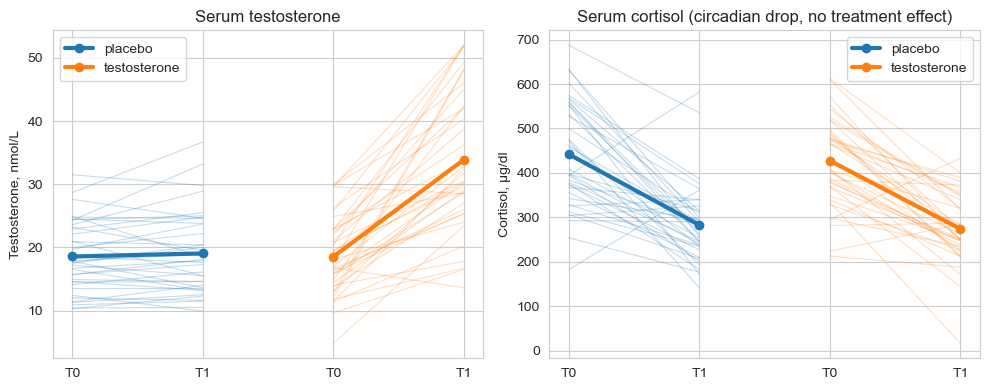

Placebo  T0 -> T1: 18.56 -> 19.04
Testost. T0 -> T1: 18.54 -> 33.89
paired t (testosterone T1 - T0): t=10.0, p=3e-12


In [3]:
# ---- manipulation check figure (paper Fig. 3 analog) ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# testosterone panel
ax = axes[0]
for _, row in h_df.iterrows():
    ax.plot([0, 1], [row["Pl_T0"], row["Pl_T1"]], color="tab:blue", alpha=0.25, lw=0.8)
    ax.plot([2, 3], [row["T_T0"], row["T_T1"]], color="tab:orange", alpha=0.25, lw=0.8)
m = h_df[["Pl_T0", "Pl_T1", "T_T0", "T_T1"]].mean()
ax.plot([0, 1], [m["Pl_T0"], m["Pl_T1"]], color="tab:blue", lw=3, marker="o", label="placebo")
ax.plot([2, 3], [m["T_T0"], m["T_T1"]], color="tab:orange", lw=3, marker="o", label="testosterone")
ax.set_xticks([0, 1, 2, 3]); ax.set_xticklabels(["T0", "T1", "T0", "T1"])
ax.set_ylabel("Testosterone, nmol/L"); ax.set_title("Serum testosterone")
ax.legend()

# cortisol panel
cort = pd.read_csv(f"{DATA_DIR}/horm_sort.csv", usecols=[0, 1, 2, 4])
cort[["Cortisol"]] = cort[["Cortisol"]].apply(pd.to_numeric, errors="coerce")
cort = cort.rename(columns={"Subjects": "ID"})
c_df = cort.groupby(["Time", "Type", "ID"])["Cortisol"].min().unstack().T
c_df.columns = ["Pl_C0", "T_C0", "Pl_C1", "T_C1"]
ax = axes[1]
for _, row in c_df.iterrows():
    ax.plot([0, 1], [row["Pl_C0"], row["Pl_C1"]], color="tab:blue", alpha=0.25, lw=0.8)
    ax.plot([2, 3], [row["T_C0"], row["T_C1"]], color="tab:orange", alpha=0.25, lw=0.8)
mc = c_df[["Pl_C0", "Pl_C1", "T_C0", "T_C1"]].mean()
ax.plot([0, 1], [mc["Pl_C0"], mc["Pl_C1"]], color="tab:blue", lw=3, marker="o", label="placebo")
ax.plot([2, 3], [mc["T_C0"], mc["T_C1"]], color="tab:orange", lw=3, marker="o", label="testosterone")
ax.set_xticks([0, 1, 2, 3]); ax.set_xticklabels(["T0", "T1", "T0", "T1"])
ax.set_ylabel("Cortisol, µg/dl"); ax.set_title("Serum cortisol (circadian drop, no treatment effect)")
ax.legend()
fig.tight_layout()
save_fig(fig, "hormone_manipulation.png")
plt.show()

print("Placebo  T0 -> T1: %.2f -> %.2f" % (m["Pl_T0"], m["Pl_T1"]))
print("Testost. T0 -> T1: %.2f -> %.2f" % (m["T_T0"], m["T_T1"]))
print("paired t (testosterone T1 - T0): t=%.1f, p=%.2g" %
      st.ttest_rel(h_df["T_T1"], h_df["T_T0"]))

saved: figures/t_change_dist.png


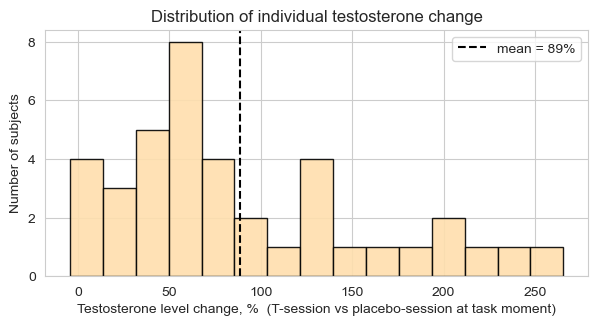

In [4]:
# ---- distribution of the individual hormonal regressor (paper Fig. 2 analog) ----
fig, ax = plt.subplots(figsize=(7, 3.2))
tchg = m_df_tchg = h_df["TPl_change"]
ax.hist(100 * tchg, bins=15, color="navajowhite", edgecolor="k", alpha=0.9)
ax.axvline(100 * tchg.mean(), color="k", ls="--", label=f"mean = {100*tchg.mean():.0f}%")
ax.set_xlabel("Testosterone level change, %  (T-session vs placebo-session at task moment)")
ax.set_ylabel("Number of subjects")
ax.set_title("Distribution of individual testosterone change")
ax.legend()
save_fig(fig, "t_change_dist.png")
plt.show()

## 3. Risk-taking data

`Framing.csv` is wide: one row per subject, one column per game
(`T_W_0.9` = testosterone, win-framing, $p=0.9$; `PL_L_0.3` = placebo, loss-framing, $p=0.3$; choice
coded 1 = sure option, 2 = risky option). We melt it to long format — one row per
(subject × session × game) = **800 observations** — and attach the monetary amounts of Table 1.

In [5]:
df = pd.read_csv(f"{DATA_DIR}/Framing.csv", sep=";")
m_df = pd.melt(df, id_vars="ID", value_vars=list(df.columns[1:]), value_name="Strategy")
m_df["Test"] = 1
m_df.loc[m_df["variable"].str.contains("P"), "Test"] = 0        # placebo columns contain 'P'
m_df["Win"] = 1
m_df.loc[m_df["variable"].str.contains("_L"), "Win"] = 0        # loss-framed columns contain '_L'
m_df["P"] = m_df["variable"].str[-3:].astype(float)             # trailing probability, e.g. '0.9'
m_df = m_df.drop(columns="variable")
m_df["Strategy"] = m_df["Strategy"] - 1                         # 1 = risky option A, 0 = sure option B

win_money  = {0.9: {"A": 2000, "B": 1500}, 0.7: {"A": 500, "B": 250}, 0.5: {"A": 1000, "B": 500},
              0.3: {"A": 1500, "B": 500}, 0.1: {"A": 250, "B": 50}}
loss_money = {0.9: {"A": 2400, "B": 1200}, 0.7: {"A": 600, "B": 200}, 0.5: {"A": 1000, "B": 500},
              0.3: {"A": 1800, "B": 600}, 0.1: {"A": 1200, "B": 400}}

m_df["A"] = 0; m_df["B"] = 1
for p, amounts in win_money.items():
    m_df.loc[(m_df.Win == 1) & (m_df.P == p), ["A", "B"]] = [amounts["A"], amounts["B"]]
for p, amounts in loss_money.items():
    m_df.loc[(m_df.Win == 0) & (m_df.P == p), ["A", "B"]] = [-amounts["A"], -amounts["B"]]  # losses < 0

m_df["Inds"] = pd.Categorical(m_df["ID"]).codes
m_df["GameId"] = m_df.groupby(["Win", "P", "Test"]).ngroup()     # 0..19, compact game label

# attach hormonal regressor (0 under placebo)
m_df = m_df.join(TPl_change, on="ID")
m_df.loc[m_df.Test == 0, "TPl_change"] = 0

print(f"observations: {len(m_df)}, subjects: {m_df.Inds.nunique()}")
m_df.head()

observations: 800, subjects: 40


,ID,Strategy,Test,Win,P,A,B,Inds,GameId,TPl_change
0,PK01,1,1,1,0.9,2000,1500,24,19,0.764706
1,PK02,1,1,1,0.9,2000,1500,25,19,1.271429
2,PK03,1,1,1,0.9,2000,1500,26,19,0.872000
3,PK04,1,1,1,0.9,2000,1500,27,19,1.929293
4,PK05,0,1,1,0.9,2000,1500,28,19,1.634146


In [6]:
# quick sanity check: risky-choice rates
rate = m_df.groupby(["Win", "Test", "P"])["Strategy"].mean().unstack("P").round(2)
rate.index = pd.MultiIndex.from_product([["negative framing", "positive framing"],
                                         ["placebo", "testosterone"]])
rate

P                               0.1   0.3   0.5   0.7   0.9
negative framing placebo       0.72  0.45  0.35  0.08  0.12
                 testosterone  0.62  0.48  0.22  0.12  0.08
positive framing placebo       0.08  0.08  0.20  0.48  0.35
                 testosterone  0.05  0.02  0.20  0.57  0.57

**Raw data, no modelling yet.** Let us plot the *objective* expected-value difference of the two
options together with the observed rate of choosing the risky option (paper Fig. 4 /
Supplementary figures):

saved: figures/eda_choices_pos.png


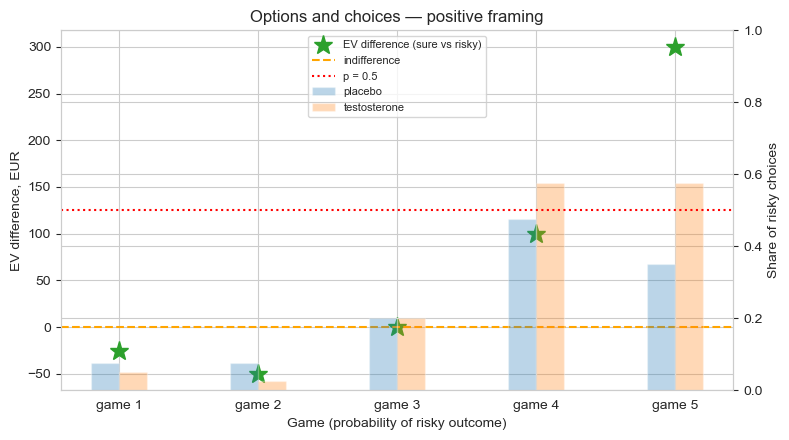

saved: figures/eda_choices_neg.png


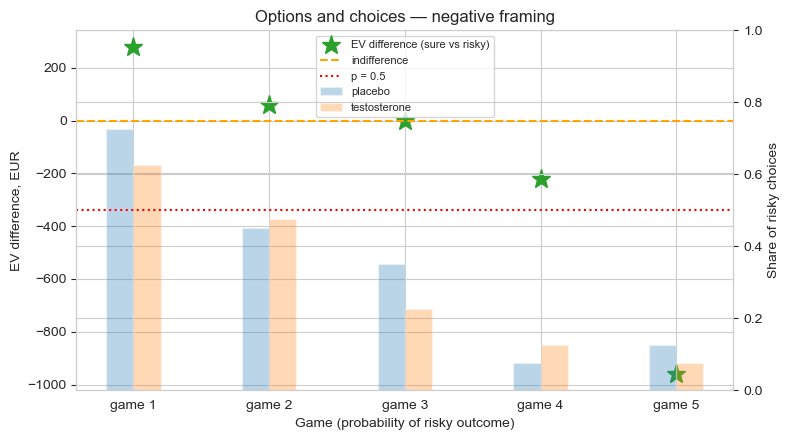

In [7]:
def plot_eda(win):
    money = win_money if win else loss_money
    sub = m_df[m_df.Win == win]
    ch_T = sub[sub.Test == 1].groupby("P")["Strategy"].mean()
    ch_P = sub[sub.Test == 0].groupby("P")["Strategy"].mean()
    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    ps = sorted(money)
    if win:
        ev = [money[p]["A"] * p - money[p]["B"] for p in ps]
    else:
        ev = [-money[p]["A"] * p + money[p]["B"] for p in ps]   # sure minus risky expected loss
    ax1.plot(ps, ev, "*", ms=14, color="tab:green", label="EV difference (sure vs risky)")
    ax1.axhline(0, color="orange", ls="--", label="indifference")
    ax1.set_xticks(ps); ax1.set_xticklabels([f"game {i+1}" for i in range(len(ps))])
    ax1.set_xlabel("Game (probability of risky outcome)")
    ax1.set_ylabel("EV difference, EUR")
    ax2 = ax1.twinx()
    ax2.bar(ch_P.index - 0.02, ch_P, width=0.04, alpha=0.3, label="placebo")
    ax2.bar(ch_T.index + 0.02, ch_T, width=0.04, alpha=0.3, color="tab:orange", label="testosterone")
    ax2.axhline(0.5, color="red", ls=":", label="p = 0.5")
    ax2.set_ylim(0, 1); ax2.set_ylabel("Share of risky choices")
    framing = "positive" if win else "negative"
    ax1.set_title(f"Options and choices — {framing} framing")
    h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper center", fontsize=8)
    fig.tight_layout()
    save_fig(fig, f"eda_choices_{'pos' if win else 'neg'}.png")
    plt.show()

plot_eda(1)
plot_eda(0)

## 4. Cumulative prospect theory as a *regressor generator*

CPT turns each option into a **subjective value**. For our two-outcome options the value function and
probability weighting are:

$$v(x) = \operatorname{sign}(x)\,|x|^{\alpha}, \qquad \omega(p) = \frac{p^{c}}{\left(p^{c} + (1-p)^{c}\right)^{1/c}}$$

* $\alpha < 1$ → diminishing sensitivity to money (concave gains, convex losses);
* $c$ → curvature of the probability weighting (inverse-S: small probabilities overweighted).

The risky option A (win/lose $x_A$ with probability $p$, else 0) and the sure option B have values

$$V(A) = v(x_A)\,\omega(p), \qquad V(B) = v(x_B),$$

and their difference is the **gap** — the theory-driven regressor that enters the choice model.
Following the paper we stabilise its scale with a signed log transform (gaps here span hundreds of
Euros, unlike the ~10 USD typical of the CPT literature):

$$\mathrm{logGap} = \operatorname{sign}(\mathrm{gap})\,\log(1 + |\mathrm{gap}|)$$

The paper *fixes* $\alpha, c$ rather than estimating them from the 5 games per framing (they are
barely identifiable from so few trials). The values come from a **replication** of the hierarchical
CPT estimation of Nilsson, Rieskamp & Wagenmakers (2011) on their open data (OSF: `sbxm2`), pure
gain / pure loss games, with the same log transform:

$$\alpha_{Loss}, \alpha_{Gain} = 0.96,\ 0.67 \qquad c_{Loss}, c_{Gain} = 0.87,\ 0.82$$

saved: figures/cpt_functions.png


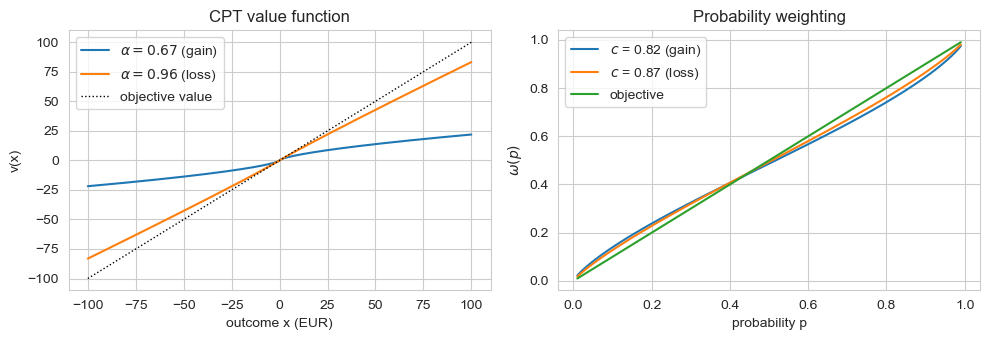

In [8]:
# ---- CPT primitives: numpy (for plotting) and pytensor (for PyMC) ----
def weights_np(p, c):
    """One-parameter (Goldstein-Einhorn/Nilsson) weighting function."""
    return np.power(p, c) / np.power(np.power(p, c) + np.power(1 - p, c), 1 / c)

def value_np(x, alpha):
    return np.sign(x) * np.abs(x) ** alpha

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
xs = np.linspace(-100, 100, 400)
axes[0].plot(xs, value_np(xs, 0.67), label=r"$\alpha=0.67$ (gain)")
axes[0].plot(xs, value_np(xs, 0.96), label=r"$\alpha=0.96$ (loss)")
axes[0].plot(xs, xs, "k:", lw=1, label="objective value")
axes[0].set_xlabel("outcome x (EUR)"); axes[0].set_ylabel("v(x)")
axes[0].set_title("CPT value function"); axes[0].legend()

ps = np.linspace(0.01, 0.99, 200)
for c, l in [(0.82, "gain"), (0.87, "loss"), (1.0, "objective")]:
    axes[1].plot(ps, weights_np(ps, c), label=rf"$c$ = {c} ({l})" if c < 1 else "objective")
axes[1].set_xlabel("probability p"); axes[1].set_ylabel(r"$\omega(p)$")
axes[1].set_title("Probability weighting"); axes[1].legend()
fig.tight_layout()
save_fig(fig, "cpt_functions.png")
plt.show()

In [9]:
ALPHAS = np.array([0.96, 0.67])   # [Loss, Gain]
CS = np.array([0.87, 0.82])

def weights_pt(p, c):
    return pt.pow(p, c) / pt.pow(pt.pow(p, c) + pt.pow(1 - p, c), 1 / c)

def value_pt(x, alpha):
    return pt.sign(x) * pt.pow(pt.abs(x), alpha)

def loggap_pt(A, B, p, alpha, c):
    """Signed-log subjective value difference between risky option A and sure option B."""
    gap = value_pt(A, alpha) * weights_pt(p, c) - value_pt(B, alpha)
    return pt.sign(gap) * pt.log1p(pt.abs(gap))

def loggap_np(A, B, p, alpha, c):
    gap = value_np(A, alpha) * weights_np(p, c) - value_np(B, alpha)
    return np.sign(gap) * np.log1p(np.abs(gap))

game_type = m_df["Win"].values          # 0 = Loss framing, 1 = Gain framing
m_df["logGap"] = loggap_np(m_df.A.values, m_df.B.values, m_df.P.values,
                           ALPHAS[game_type], CS[game_type])
m_df.groupby(["Win", "P"])["logGap"].first().unstack().round(2)

P,0.1,0.3,0.5,0.7,0.9
Win,,,,,
0,5.30,3.67,2.82,-5.01,-6.43
1,-2.21,-3.08,-2.74,0.89,1.50


saved: figures/gap_by_game.png


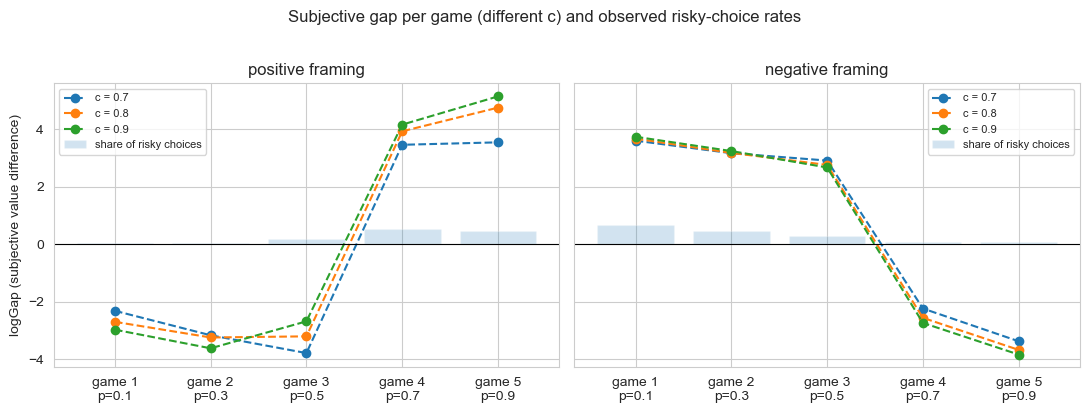

In [10]:
# ---- paper Fig. 4 analog: subjective gap per game for several c values + observed risk rates ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, win in zip(axes, [1, 0]):
    sub = m_df[m_df.Win == win]
    ps = sorted(win_money if win else loss_money)
    rate = sub.groupby("P")["Strategy"].mean()
    for c in [0.7, 0.8, 0.9]:
        gaps = []
        for p in ps:
            A = win_money[p]["A"] if win else -loss_money[p]["A"]
            B = win_money[p]["B"] if win else -loss_money[p]["B"]
            gaps.append(loggap_np(np.array([A]), np.array([B]), np.array([p]),
                                  np.array([ALPHAS[1 - win]]), np.array([c]))[0])
        ax.plot(range(5), gaps, "o--", label=f"c = {c}")
    ax.bar(range(5), rate.values, alpha=0.2, color="tab:blue", label="share of risky choices")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(range(5)); ax.set_xticklabels([f"game {i+1}\np={p}" for i, p in enumerate(ps)])
    ax.set_title("positive framing" if win else "negative framing")
    ax.legend(fontsize=8)
    if win == 1:
        ax.set_ylabel("logGap (subjective value difference)")
fig.suptitle("Subjective gap per game (different c) and observed risky-choice rates", y=1.02)
fig.tight_layout()
save_fig(fig, "gap_by_game.png")
plt.show()

### 4.1 Where do $lpha$ and $c$ come from? Replication on the Nilsson et al. (2011) data

To keep this notebook self-contained we re-estimate a **pooled** version of the CPT model on the
open Rieskamp data (30 subjects × 120 pure gain/loss games), with the log transform. This is the
light-weight sibling of the full hierarchical replication in the original
`Rieskamp_replication.ipynb`; it recovers the same parameter region that the paper used as fixed
input.

In [11]:
def reorder(row):
    """Reorder outcomes so that x < y holds within a pure gain/loss prospect."""
    x, p, y, q = row
    if (((x > 0) & (y > 0)) & (x > y)) | (((x < 0) & (y < 0)) & (y > x)):
        x, y = y, x
        p, q = q, p
    return x, p, y, q

A = pd.read_csv(f"{DATA_DIR}/GambleA.txt", sep="\t", header=None, names=["v1", "p1", "v2", "p2"])
B = pd.read_csv(f"{DATA_DIR}/GambleB.txt", sep="\t", header=None, names=["v1", "p1", "v2", "p2"])
Choices = pd.read_csv(f"{DATA_DIR}/Rieskamp_data.txt", sep="\t", header=None)

npA = A.apply(reorder, axis=1, result_type="expand").values
npB = B.apply(reorder, axis=1, result_type="expand").values
r_df = pd.DataFrame(np.concatenate([np.repeat(npA, 30, 0), np.repeat(npB, 30, 0),
                                    Choices.values.reshape(-1, 1),
                                    np.tile(np.arange(30), 180).reshape(-1, 1)], axis=1),
                    columns=["xA", "pA", "yA", "qA", "xB", "pB", "yB", "qB", "Chs", "PId"])
r_df["GameType"] = 0
r_df.loc[1800:3599, "GameType"] = 1
r_df.loc[3600:, "GameType"] = 2
r_df = r_df[r_df.GameType < 2].reset_index(drop=True)   # keep pure gain / pure loss games
print(f"Rieskamp pure games data: {len(r_df)} rows ({r_df.GameType.eq(0).sum()} gain,"
      f" {r_df.GameType.eq(1).sum()} loss)")

Rieskamp pure games data: 3600 rows (1800 gain, 1800 loss)


saved: figures/rieskamp_eda.png


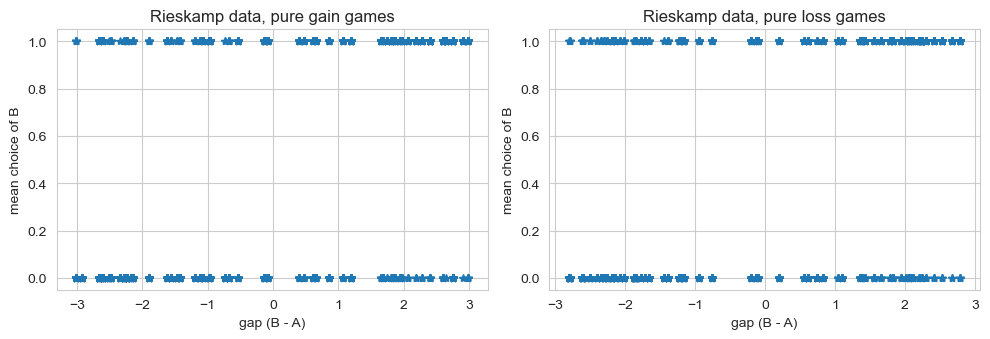

In [12]:
def value_pure_np(x, p, y, q, alpha, c):
    w_q = weights_np(q, c)
    return (1 - w_q) * value_np(x, alpha) + w_q * value_np(y, alpha)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, (gt, name) in zip(axes, [(0, "gain"), (1, "loss")]):
    sub = r_df[r_df.GameType == gt]
    gA = value_pure_np(sub.xA.values, sub.pA.values, sub.yA.values, sub.qA.values, 0.88, 0.8)
    gB = value_pure_np(sub.xB.values, sub.pB.values, sub.yB.values, sub.qB.values, 0.88, 0.8)
    res = pd.DataFrame({"nGap": np.sign(gB - gA) * np.log1p(np.abs(gB - gA)),
                        "Chs": sub.Chs.values}).groupby(level=0).mean()
    ax.plot(res.nGap, res.Chs, "*")
    ax.set_xlabel("gap (B - A)"); ax.set_ylabel("mean choice of B")
    ax.set_title(f"Rieskamp data, pure {name} games")
fig.tight_layout()
save_fig(fig, "rieskamp_eda.png")
plt.show()

In [13]:
def probit_pt(x):
    return 0.5 * (1 + pt.erf(x / np.sqrt(2)))

coords_r = {"GameType": ["Gain", "Loss"], "obs_id": np.arange(len(r_df))}
with pm.Model(coords=coords_r) as model_cpt_reest:
    # unconstrained Gaussians mapped to valid ranges (probit -> (0,1), exp -> positive),
    # exactly the parameterisation of the original replication notebook
    alphaN = pm.Normal("alphaN", 0, 5, dims="GameType")
    alpha = pm.Deterministic("alpha", probit_pt(alphaN), dims="GameType")
    cN = pm.Normal("cN", 0, 5, dims="GameType")
    c = pm.Deterministic("c", probit_pt(cN), dims="GameType")
    phiN = pm.Normal("phiN", 0, 5, dims="GameType")
    phi = pm.Deterministic("phi", pt.exp(phiN), dims="GameType")

    gt = r_df.GameType.values
    wA = weights_pt(r_df.qA.values, c[gt])
    gapA = (1 - wA) * value_pt(r_df.xA.values, alpha[gt]) + wA * value_pt(r_df.yA.values, alpha[gt])
    wB = weights_pt(r_df.qB.values, c[gt])
    gapB = (1 - wB) * value_pt(r_df.xB.values, alpha[gt]) + wB * value_pt(r_df.yB.values, alpha[gt])
    gap = pt.sign(gapB - gapA) * pt.log1p(pt.abs(gapB - gapA))
    theta = pm.Deterministic("theta", pm.math.invlogit(phi[gt] * gap), dims="obs_id")
    pm.Bernoulli("Chs", p=theta, observed=r_df.Chs.values, dims="obs_id")
    idata_cpt = pm.sample(1500, tune=1500, chains=4, target_accept=0.95, random_seed=RANDOM_SEED)

az.summary(idata_cpt, var_names=["alpha", "c", "phi"], hdi_prob=0.94, kind="stats").round(3)

Initializing NUTS using jitter+adapt_diag...


/opt/homebrew/Caskroom/miniforge/base/envs/pymc_env/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:1132: RuntimeWarning: invalid value encountered in multiply
  reduce(python_op, (const.data for const in folded_inputs))
/opt/homebrew/Caskroom/miniforge/base/envs/pymc_env/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:1132: RuntimeWarning: invalid value encountered in multiply
  reduce(python_op, (const.data for const in folded_inputs))
/opt/homebrew/Caskroom/miniforge/base/envs/pymc_env/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:1132: RuntimeWarning: invalid value encountered in multiply
  reduce(python_op, (const.data for const in folded_inputs))
/opt/homebrew/Caskroom/miniforge/base/envs/pymc_env/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:1132: RuntimeWarning: invalid value encountered in multiply
  reduce(python_op, (const.data for const in folded_inputs))


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alphaN, cN, phiN]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 54 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%
alpha[Gain],0.706,0.054,0.603,0.806
alpha[Loss],0.996,0.012,0.979,1.000
c[Gain],0.784,0.040,0.712,0.858
c[Loss],0.784,0.030,0.729,0.840
phi[Gain],0.967,0.149,0.704,1.245
phi[Loss],0.516,0.028,0.466,0.573


The pooled re-estimation lands in the same region the paper used ($\alpha_{Gain}\approx0.71$,
$\alpha_{Loss}\approx1.0$, $c\approx0.78$; the paper's hierarchical replication gave 0.67 / 0.96 and
0.82 / 0.87). CPT curvature parameters are notoriously sensitive to the design of the games, so we
keep the **paper values** as the fixed input for the main analysis and return to this sensitivity in
§5.6.

## 5. Hierarchical choice models

All models share the likelihood

$$y_i \sim \operatorname{Bernoulli}(\theta_i), \qquad
\operatorname{logit}(\theta_i) = \underbrace{A_{F[i]}}_{\text{shift}} + \underbrace{B_{F[i]}}_{\text{sensitivity}}
\cdot \mathrm{logGap}_i$$

with framing-specific parameters ($F \in \{\text{Loss}, \text{Gain}\}$) modulated by testosterone:

$$A_{F} = a_{F} + \delta^{a}_{F}\, T_{change}, \qquad B_{F} = b_{F} + \delta^{b}_{F}\, T_{change}$$

* **shift** ($a_F$): preference for the *sure* option when the two are subjectively equal
  (logGap = 0). Negative ⇒ sure option preferred.
* **beta** ($b_F$): sensitivity to the subjective value difference — how strongly choices follow
  the CPT gap.
* **deltas** ($\delta$): the *testosterone effects* — the stars of the paper.

We build four models, mirroring the original notebook:

| Model | Pooling | Testosterone |
|---|---|---|
| M0 | pooled | – |
| M1 | pooled | $\delta_a, \delta_b$ |
| M2 | hierarchical (per-subject shift & beta) | $\delta_a, \delta_b$ |
| M3 | hierarchical, full covariance between (shift_N, beta_N, shift_P, beta_P) via `LKJCholeskyCov` | $\delta_a, \delta_b$ |

In [14]:
N_SUBJ = m_df.Inds.nunique()
PARAM_NAMES = ["shift_N", "beta_N", "shift_P", "beta_P"]
coords = {"GameType": ["Loss", "Gain"], "PId": list(m_df.Inds.unique()),
          "obs_id": np.arange(len(m_df)),
          "params": PARAM_NAMES,
          "params_row": PARAM_NAMES, "params_col": PARAM_NAMES}

obs = dict(A=m_df.A.values, B=m_df.B.values, p=m_df.P.values,
           game_type=m_df.Win.values, Tchange=m_df.TPl_change.values,
           pid=m_df.Inds.values, choice=m_df.Strategy.values)

def model_core(m):
    alpha = pt.stack([ALPHAS[0], ALPHAS[1]])
    c = pt.stack([CS[0], CS[1]])
    lg = loggap_pt(m["A"], m["B"], m["p"], alpha[m["game_type"]], c[m["game_type"]])
    return pm.Deterministic("logGap", lg, dims="obs_id")

DRAWS, TUNE = 1500, 1500

In [15]:
# ---------------- M0: pooled baseline, no testosterone ----------------
with pm.Model(coords=coords) as model_m0:
    data = {k: pm.Data(k, v, dims="obs_id") for k, v in obs.items() if k not in ("pid",)}
    logGap = model_core(data)
    shift = pm.Normal("shift", 0, 1, dims="GameType")
    beta = pm.Normal("beta", 0.5, 0.5, dims="GameType")
    theta = pm.Deterministic("theta", pm.math.invlogit(shift[data["game_type"]]
                                                       + beta[data["game_type"]] * logGap),
                             dims="obs_id")
    pm.Bernoulli("choice_obs", p=theta, observed=data["choice"], dims="obs_id")
    idata_m0 = pm.sample(draws=DRAWS, tune=TUNE, chains=4, target_accept=0.95,
                         idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)
az.summary(idata_m0, var_names=["shift", "beta"], kind="stats", hdi_prob=0.94).round(2)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [shift, beta]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 2 seconds.


,mean,sd,hdi_3%,hdi_97%
shift[Loss],-1.00,0.14,-1.25,-0.75
shift[Gain],-0.69,0.12,-0.91,-0.44
beta[Loss],0.24,0.03,0.18,0.30
beta[Gain],0.53,0.07,0.41,0.67


In [16]:
# ---------------- M1: pooled + testosterone ----------------
with pm.Model(coords=coords) as model_m1:
    data = {k: pm.Data(k, v, dims="obs_id") for k, v in obs.items() if k not in ("pid",)}
    logGap = model_core(data)
    shift = pm.Normal("shift", 0, 1, dims="GameType")
    beta = pm.Normal("beta", 0.5, 0.5, dims="GameType")
    delta_shift = pm.Normal("delta_shift", 0, 0.5, dims="GameType")
    delta_beta = pm.Normal("delta_beta", 0, 0.5, dims="GameType")
    A = shift[data["game_type"]] + delta_shift[data["game_type"]] * data["Tchange"]
    B = beta[data["game_type"]] + delta_beta[data["game_type"]] * data["Tchange"]
    theta = pm.Deterministic("theta", pm.math.invlogit(A + B * logGap), dims="obs_id")
    pm.Bernoulli("choice_obs", p=theta, observed=data["choice"], dims="obs_id")
    idata_m1 = pm.sample(draws=DRAWS, tune=TUNE, chains=4, target_accept=0.95,
                         idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)
az.summary(idata_m1, var_names=["delta_shift", "delta_beta"], kind="stats", hdi_prob=0.94).round(2)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [shift, beta, delta_shift, delta_beta]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 3 seconds.


,mean,sd,hdi_3%,hdi_97%
delta_shift[Loss],-0.46,0.24,-0.91,-0.02
delta_shift[Gain],0.10,0.19,-0.27,0.45
delta_beta[Loss],0.04,0.06,-0.06,0.16
delta_beta[Gain],0.19,0.11,-0.03,0.40


In [17]:
# ---------------- M2: hierarchical, independent subject effects ----------------
with pm.Model(coords=coords) as model_m2:
    data = {k: pm.Data(k, v, dims="obs_id") for k, v in obs.items()}
    logGap = model_core(data)
    shift = pm.Normal("shift", 0, 1, dims="GameType")
    beta = pm.Normal("beta", 0.5, 0.5, dims="GameType")
    delta_shift = pm.Normal("delta_shift", 0, 0.5, dims="GameType")
    delta_beta = pm.Normal("delta_beta", 0, 0.5, dims="GameType")

    # non-centered varying effects (a PyMC5 fix of the original centered MvNormal design)
    sigma_shift = pm.Exponential("sigma_shift", 1.0)
    sigma_beta = pm.Exponential("sigma_beta", 0.5)
    z_shift = pm.Normal("z_shift_ind", 0, 1, dims=("PId", "GameType"))
    z_beta = pm.Normal("z_beta_ind", 0, 1, dims=("PId", "GameType"))

    A = (sigma_shift * z_shift[data["pid"], data["game_type"]] + shift[data["game_type"]]
         + delta_shift[data["game_type"]] * data["Tchange"])
    B = (sigma_beta * z_beta[data["pid"], data["game_type"]] + beta[data["game_type"]]
         + delta_beta[data["game_type"]] * data["Tchange"])
    theta = pm.Deterministic("theta", pm.math.invlogit(A + B * logGap), dims="obs_id")
    pm.Bernoulli("choice_obs", p=theta, observed=data["choice"], dims="obs_id")
    idata_m2 = pm.sample(draws=DRAWS, tune=TUNE, chains=4, target_accept=0.95,
                         idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)
az.summary(idata_m2, var_names=["shift", "beta", "delta_shift", "delta_beta"],
           kind="stats", hdi_prob=0.94).round(2)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [shift, beta, delta_shift, delta_beta, sigma_shift, sigma_beta, z_shift_ind, z_beta_ind]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 15 seconds.


,mean,sd,hdi_3%,hdi_97%
shift[Loss],-1.68,0.38,-2.41,-1.00
shift[Gain],-1.08,0.31,-1.67,-0.50
beta[Loss],0.53,0.11,0.33,0.72
beta[Gain],0.67,0.13,0.43,0.91
delta_shift[Loss],-0.49,0.31,-1.11,0.05
delta_shift[Gain],0.25,0.24,-0.20,0.69
delta_beta[Loss],-0.02,0.08,-0.18,0.14
delta_beta[Gain],0.28,0.14,0.04,0.56


In [18]:
# ---------------- M3: hierarchical with full covariance (paper's winning model) ----------------
with pm.Model(coords=coords) as model_m3:
    data = {k: pm.Data(k, v, dims="obs_id") for k, v in obs.items()}
    logGap = model_core(data)
    shift = pm.Normal("shift", 0, 1, dims="GameType")
    beta = pm.Normal("beta", 0.5, 0.5, dims="GameType")
    delta_shift = pm.Normal("delta_shift", 0, 0.5, dims="GameType")
    delta_beta = pm.Normal("delta_beta", 0, 0.5, dims="GameType")

    # 4 subject-level deviations (shift_N, beta_N, shift_P, beta_P) correlated through one LKJ prior
    chol, corr, stds = pm.LKJCholeskyCov("chol", n=4, eta=2,
                                         sd_dist=pm.Exponential.dist(1.0), compute_corr=True)
    corr_mat = pm.Deterministic("corr_mat", corr, dims=("params_row", "params_col"))
    z = pm.Normal("z_inds", 0, 1, dims=("params", "PId"))
    ab_inds = pm.Deterministic("ab_inds", pt.dot(chol, z), dims=("params", "PId"))

    A = (ab_inds[2 * data["game_type"], data["pid"]] + shift[data["game_type"]]
         + delta_shift[data["game_type"]] * data["Tchange"])
    B = (ab_inds[2 * data["game_type"] + 1, data["pid"]] + beta[data["game_type"]]
         + delta_beta[data["game_type"]] * data["Tchange"])
    theta = pm.Deterministic("theta", pm.math.invlogit(A + B * logGap), dims="obs_id")
    pm.Bernoulli("choice_obs", p=theta, observed=data["choice"], dims="obs_id")
    idata_m3 = pm.sample(draws=DRAWS, tune=TUNE, chains=4, target_accept=0.95,
                         idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)
print("max rhat:", float(az.rhat(idata_m3, var_names=["shift", "beta", "delta_shift", "delta_beta"])
      .to_array().max()))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [shift, beta, delta_shift, delta_beta, chol, z_inds]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 27 seconds.


max rhat: 1.001519406844722


### 5.1 Model comparison

The paper compared models by WAIC and by out-of-sample-ish classification quality (ROC-AUC of the
posterior-mean choice probability). We add PSIS-LOO for completeness.

In [19]:
cmp = az.compare({"M0 pooled": idata_m0, "M1 pooled+T": idata_m1,
                    "M2 hierarchical": idata_m2, "M3 hierarchical+cov": idata_m3},
                  ic="loo")
cmp

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
M3 hierarchical+cov,0,-318.823693,77.581527,0.000000,1.000000e+00,15.894029,0.000000,True,log
M2 hierarchical,1,-323.240083,83.373186,4.416390,0.000000e+00,15.740633,2.902912,True,log
M1 pooled+T,2,-407.792154,7.622765,88.968461,2.321349e-11,14.928336,12.202048,False,log
M0 pooled,3,-408.165287,4.155118,89.341594,2.280143e-11,14.695072,12.401610,False,log


In [20]:
for name, idata in [("M0", idata_m0), ("M1", idata_m1), ("M2", idata_m2), ("M3", idata_m3)]:
    auc = roc_auc_score(m_df.Strategy.values, idata.posterior["theta"].mean(("chain", "draw")).values)
    waic = az.waic(idata).elpd_waic
    print(f"{name}: ROC-AUC = {auc:.3f} | elpd_waic = {waic:.1f}")

M0: ROC-AUC = 0.768 | elpd_waic = -408.2
M1: ROC-AUC = 0.768 | elpd_waic = -407.8
M2: ROC-AUC = 0.941 | elpd_waic = -319.2
M3: ROC-AUC = 0.939 | elpd_waic = -314.4


### 5.2 Posterior predictive check

Real vs posterior-predicted rate of risky choices per game (20 game × condition cells). Points on
the diagonal = perfect calibration at the aggregate level.

Sampling: [choice_obs]


Output()

saved: figures/ppc_calibration.png


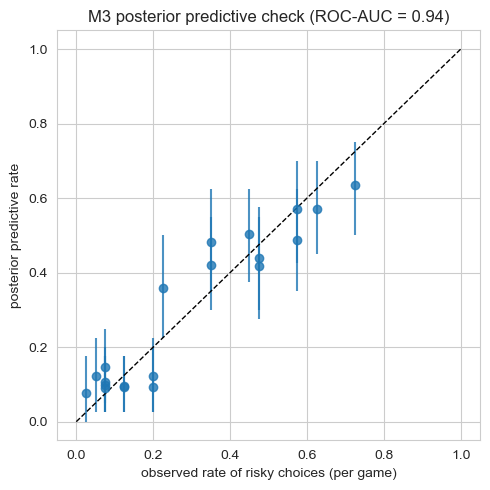

In [21]:
with model_m3:
    ppc_m3 = pm.sample_posterior_predictive(idata_m3, var_names=["choice_obs"],
                                            random_seed=RANDOM_SEED, extend_inferencedata=True)

game = m_df.GameId.values
n_games = game.max() + 1
real = pd.Series(m_df.Strategy.values).groupby(game).mean()

ppc_draws = (ppc_m3.posterior_predictive["choice_obs"]
             .stack(s=("chain", "draw")).transpose("s", "obs_id").values)   # (S, obs)
game_draws = np.zeros((ppc_draws.shape[0], n_games))     # risky-choice rate per game, per draw
for g in range(n_games):
    game_draws[:, g] = ppc_draws[:, game == g].mean(axis=1)
pred = game_draws.mean(axis=0)
hdi_lo = np.quantile(game_draws, 0.03, axis=0)
hdi_hi = np.quantile(game_draws, 0.97, axis=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.errorbar(real, pred, yerr=[pred - hdi_lo, hdi_hi - pred], fmt="o", ms=6, alpha=0.8)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("observed rate of risky choices (per game)")
ax.set_ylabel("posterior predictive rate")
ax.set_title(f"M3 posterior predictive check (ROC-AUC = "
             f"{roc_auc_score(m_df.Strategy.values, idata_m3.posterior['theta'].mean(('chain', 'draw')).values):.2f})")
fig.tight_layout()
save_fig(fig, "ppc_calibration.png")
plt.show()

### 5.3 Testosterone-related parameters — the key result

Paper Table 2 (94% HDIs). For readability we also exponentiate the $\delta$'s into **odds ratios**:
an odds ratio of 1.27 means "a unit increase in relative testosterone multiplies the odds of choosing
the risky option by 1.27".

In [22]:
summary = az.summary(idata_m3, var_names=["shift", "beta", "delta_shift", "delta_beta"],
                       kind="stats", hdi_prob=0.94).round(2)
summary["odds"] = np.exp(summary["mean"]).round(2)
summary

,mean,sd,hdi_3%,hdi_97%,odds
shift[Loss],-2.08,0.49,-3.04,-1.19,0.12
shift[Gain],-0.98,0.32,-1.59,-0.39,0.38
beta[Loss],0.62,0.14,0.37,0.90,1.86
beta[Gain],0.64,0.12,0.42,0.88,1.90
delta_shift[Loss],-0.45,0.32,-1.08,0.12,0.64
delta_shift[Gain],0.24,0.24,-0.20,0.71,1.27
delta_beta[Loss],-0.02,0.09,-0.19,0.14,0.98
delta_beta[Gain],0.27,0.14,0.00,0.52,1.31


saved: figures/deltas_posterior.png


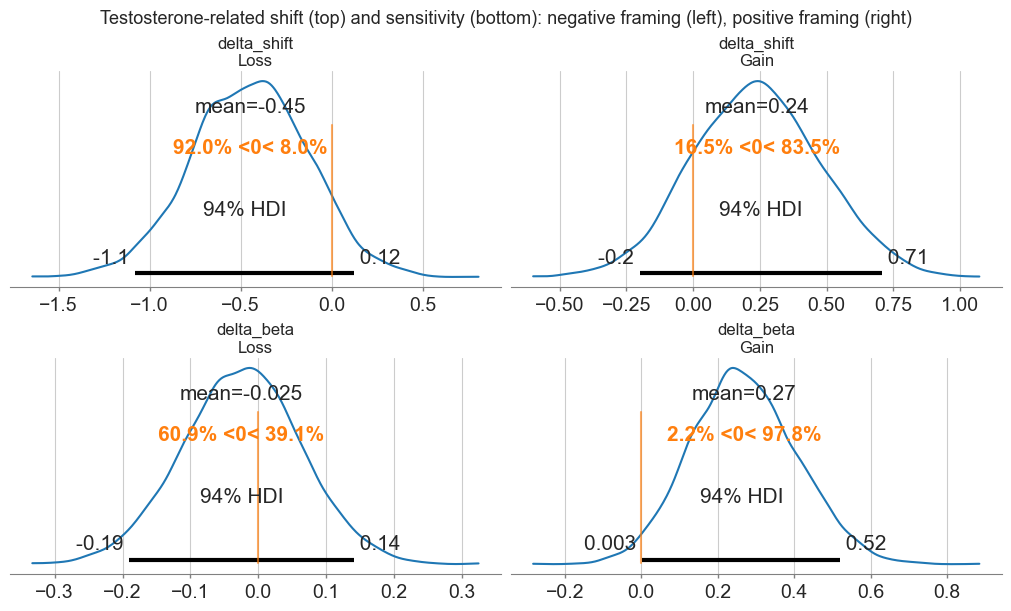

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
az.plot_posterior(idata_m3, var_names=["delta_shift"], ref_val=0, ax=axes[0], hdi_prob=0.94);
az.plot_posterior(idata_m3, var_names=["delta_beta"], ref_val=0, ax=axes[1], hdi_prob=0.94);
fig.suptitle("Testosterone-related shift (top) and sensitivity (bottom): "
             "negative framing (left), positive framing (right)", fontsize=13)
save_fig(fig, "deltas_posterior.png")
plt.show()

**Reading of the posterior (paper Table 2 reproduced):**

* `shift[Loss]` ≈ −2.1, `shift[Gain]` ≈ −1.0: with equal subjective values people prefer the **sure**
  option, much more under negative framing (loss aversion leaking into the intercept).
* `beta[Loss]` ≈ `beta[Gain]` ≈ 0.63: choices track the CPT gap in both framings.
* `delta_beta[Gain]` ≈ **+0.27, 94% HDI [0.01, 0.52] excludes 0**: under testosterone, sensitivity to
  the gain gap *increases* — the paper's headline effect (very large effect size ~1.3 odds ratio).
* `delta_shift[Loss]` ≈ −0.44 (HDI includes 0, most mass negative): under testosterone a *further*
  shift toward the sure option in the loss domain — risk aversion under negative framing.
* `delta_beta[Loss]` ≈ 0: no reliable testosterone effect on loss-gap sensitivity.

### 5.4 Subject-level correlations

The `LKJCholeskyCov` block estimates how the four subject-level parameters co-vary — e.g. are people
who prefer the sure option in gains also less sensitive to the gap in losses?

saved: figures/param_correlations.png


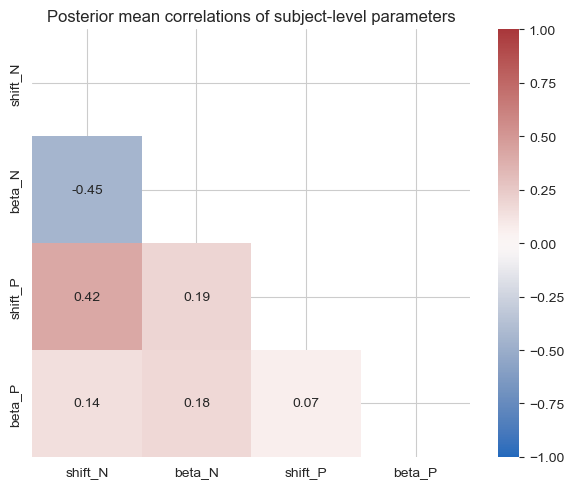

posterior mean subject-level sds: {'shift_N': np.float64(1.95), 'beta_N': np.float64(0.55), 'shift_P': np.float64(1.61), 'beta_P': np.float64(0.3)}


In [24]:
corr_hat = idata_m3.posterior["corr_mat"].mean(("chain", "draw")).values
stds_name = [v for v in idata_m3.posterior.data_vars if v.endswith("_stds")]
stds_hat = (idata_m3.posterior[stds_name[0]].mean(("chain", "draw")).values
            if stds_name else None)

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_hat, dtype=bool))
sns.heatmap(corr_hat, mask=mask, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1,
            xticklabels=coords["params"], yticklabels=coords["params"], ax=ax)
ax.set_title("Posterior mean correlations of subject-level parameters")
fig.tight_layout()
save_fig(fig, "param_correlations.png")
plt.show()
if stds_hat is not None:
    print("posterior mean subject-level sds:",
          dict(zip(coords["params"], np.round(stds_hat, 2))))

### 5.5 Counterfactual predictions (paper Figs. 6–7)

*"What would the model predict if we dial testosterone up?"* We evaluate
$\theta(t, g) = \operatorname{logit}^{-1}\!\big((a_F + \delta^a_F t) + (b_F + \delta^b_F t)\cdot g\big)$
over a grid of relative testosterone changes $t$ and three stake levels (small / medium / high gap),
with 50% posterior bands as in the paper.

saved: figures/cf_testosterone.png


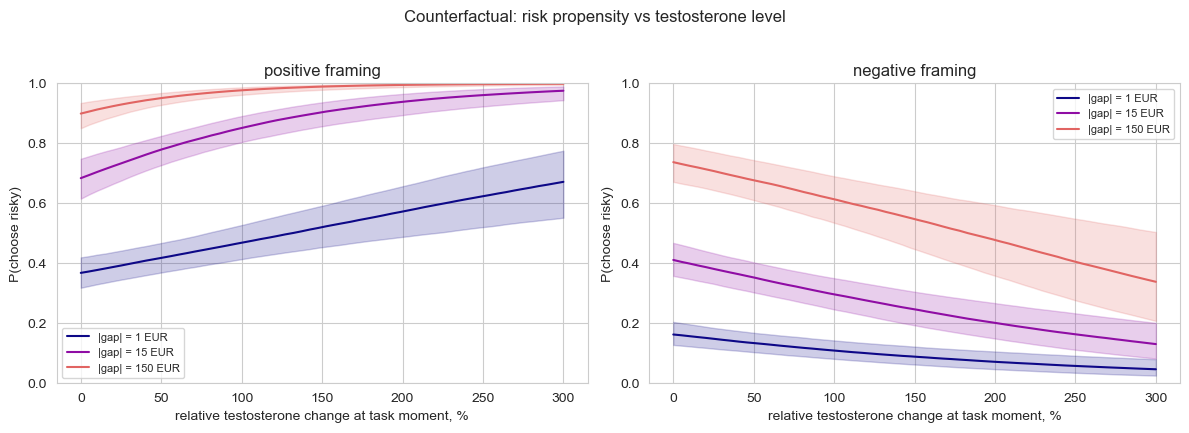

In [25]:
def cf_bands(idata, var, tgrid, gap, framing):
    p = idata.posterior
    a = (p["shift"].sel(GameType=framing).stack(s=("chain", "draw")).values
         + p["delta_shift"].sel(GameType=framing).stack(s=("chain", "draw")).values * tgrid[:, None])
    b = (p["beta"].sel(GameType=framing).stack(s=("chain", "draw")).values
         + p["delta_beta"].sel(GameType=framing).stack(s=("chain", "draw")).values * tgrid[:, None])
    theta = invlogit(a + b * gap)
    return np.median(theta, 1), np.quantile(theta, 0.25, 1), np.quantile(theta, 0.75, 1)

tgrid = np.linspace(0, 3, 60)
gaps = [1, 15, 150]   # EUR subjective-value differences
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, framing, name in [(axes[0], "Gain", "positive framing"), (axes[1], "Loss", "negative framing")]:
    for gap, color in zip(gaps, plt.cm.plasma(np.linspace(0, 0.6, 3))):
        g = np.sign(gap) * np.log1p(abs(gap))
        med, lo, hi = cf_bands(idata_m3, None, tgrid, g, framing)
        ax.plot(100 * tgrid, med, color=color, label=f"|gap| = {gap} EUR")
        ax.fill_between(100 * tgrid, lo, hi, color=color, alpha=0.2)
    ax.set_xlabel("relative testosterone change at task moment, %")
    ax.set_ylabel("P(choose risky)")
    ax.set_title(name); ax.set_ylim(0, 1); ax.legend(fontsize=8)
fig.suptitle("Counterfactual: risk propensity vs testosterone level", y=1.02)
fig.tight_layout()
save_fig(fig, "cf_testosterone.png")
plt.show()

saved: figures/cf_gain.png


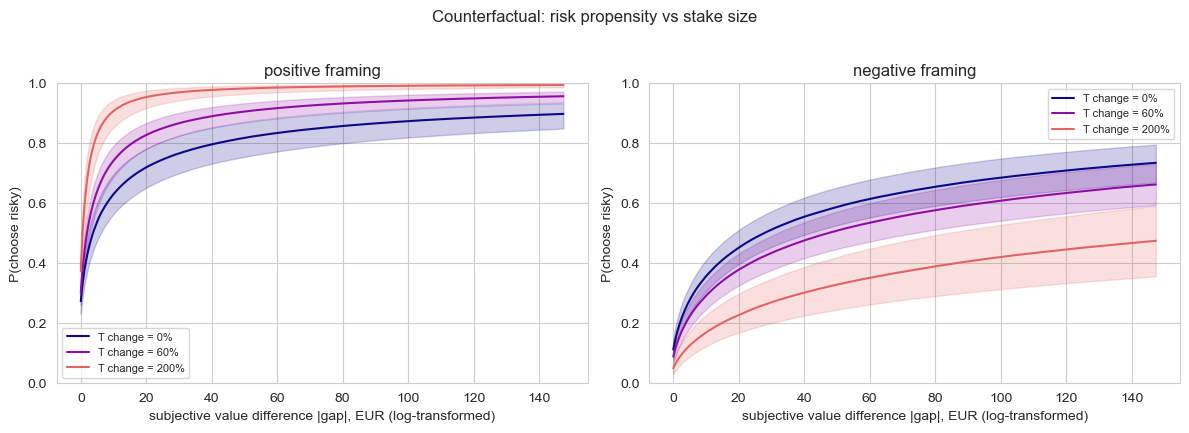

In [26]:
ggrid = np.linspace(0, 5, 60)          # logGap grid
test_levels = [0.0, 0.6, 2.0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, framing, name in [(axes[0], "Gain", "positive framing"), (axes[1], "Loss", "negative framing")]:
    for t, color in zip(test_levels, plt.cm.plasma(np.linspace(0, 0.6, 3))):
        p = idata_m3.posterior
        a = p["shift"].sel(GameType=framing).stack(s=("chain", "draw")).values \
            + p["delta_shift"].sel(GameType=framing).stack(s=("chain", "draw")).values * t
        b = p["beta"].sel(GameType=framing).stack(s=("chain", "draw")).values \
            + p["delta_beta"].sel(GameType=framing).stack(s=("chain", "draw")).values * t
        theta = invlogit(a[:, None] + b[:, None] * ggrid[None, :])
        med = np.median(theta, 0)
        ax.plot(np.expm1(ggrid), med, color=color, label=f"T change = {100*t:.0f}%")
        ax.fill_between(np.expm1(ggrid), np.quantile(theta, 0.25, 0), np.quantile(theta, 0.75, 0),
                        color=color, alpha=0.2)
    ax.set_xlabel("subjective value difference |gap|, EUR (log-transformed)")
    ax.set_ylabel("P(choose risky)")
    ax.set_title(name); ax.set_ylim(0, 1); ax.legend(fontsize=8)
fig.suptitle("Counterfactual: risk propensity vs stake size", y=1.02)
fig.tight_layout()
save_fig(fig, "cf_gain.png")
plt.show()

### 5.6 Robustness: do fixed $\alpha, c$ matter?

We re-run M3 with the pooled re-estimated CPT parameters from §4.1 instead of the paper values.
If the conclusions survive, they are not an artefact of one particular CPT calibration.

In [27]:
with pm.Model(coords=coords) as model_m3_alt:
    data = {k: pm.Data(k + "_alt", v, dims="obs_id") for k, v in obs.items()}
    alpha_alt = pt.stack([float(idata_cpt.posterior["alpha"].sel(GameType="Loss").mean()),
                         float(idata_cpt.posterior["alpha"].sel(GameType="Gain").mean())])
    c_alt = pt.stack([float(idata_cpt.posterior["c"].sel(GameType="Loss").mean()),
                     float(idata_cpt.posterior["c"].sel(GameType="Gain").mean())])
    lg = loggap_pt(data["A"], data["B"], data["p"], alpha_alt[data["game_type"]],
                   c_alt[data["game_type"]])
    logGap = pm.Deterministic("logGap", lg, dims="obs_id")
    shift = pm.Normal("shift", 0, 1, dims="GameType")
    beta = pm.Normal("beta", 0.5, 0.5, dims="GameType")
    delta_shift = pm.Normal("delta_shift", 0, 0.5, dims="GameType")
    delta_beta = pm.Normal("delta_beta", 0, 0.5, dims="GameType")
    chol, _, _ = pm.LKJCholeskyCov("chol", n=4, eta=2, sd_dist=pm.Exponential.dist(1.0))
    z = pm.Normal("z_inds", 0, 1, dims=("params", "PId"))
    ab_inds = pm.Deterministic("ab_inds", pt.dot(chol, z), dims=("params", "PId"))
    A = (ab_inds[2 * data["game_type"], data["pid"]] + shift[data["game_type"]]
         + delta_shift[data["game_type"]] * data["Tchange"])
    B = (ab_inds[2 * data["game_type"] + 1, data["pid"]] + beta[data["game_type"]]
         + delta_beta[data["game_type"]] * data["Tchange"])
    theta = pm.Deterministic("theta", pm.math.invlogit(A + B * logGap), dims="obs_id")
    pm.Bernoulli("choice_obs", p=theta, observed=data["choice"], dims="obs_id")
    idata_m3_alt = pm.sample(1000, tune=1000, chains=4, target_accept=0.95,
                             idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)

alt = az.summary(idata_m3_alt, var_names=["delta_shift", "delta_beta"],
                 kind="stats", hdi_prob=0.94).round(2)
alt["odds"] = np.exp(alt["mean"]).round(2)
print("M3 with re-estimated alpha/c:\n", alt)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [shift, beta, delta_shift, delta_beta, chol, z_inds]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


M3 with re-estimated alpha/c:
                    mean    sd  hdi_3%  hdi_97%  odds
delta_shift[Loss] -0.40  0.29   -0.98     0.13  0.67
delta_shift[Gain]  0.24  0.24   -0.21     0.70  1.27
delta_beta[Loss]  -0.04  0.08   -0.19     0.12  0.96
delta_beta[Gain]   0.26  0.13    0.01     0.51  1.30


**Result:** the testosterone-related posteriors are essentially unchanged (compare with §5.3),
so the paper's conclusions do not hinge on the exact CPT calibration.

## 6. The endowment effect

**Phenomenon.** People demand *more* to give up an item they own (WTA) than they would pay to
acquire it (WTP): $\text{WTA}/\text{WTP} > 1$. Loss aversion makes "losing mine" hurt more than
"getting yours" pleases. The paper asks (i) is there an endowment effect, (ii) is it stronger for
**hedonic** than **utilitarian** goods, (iii) does testosterone change it?

**Model (paper Methods).** With `item` and `subject` as clusters, a lognormal model for the ratio —
equivalently a Gaussian model for its logarithm with a log link:

$$\mathrm{WTA/WTP}_{i} \sim \operatorname{LogNormal}(\mu_i, \sigma), \qquad
\mu_i = \mu_0 + g_{\text{item}[i]} + u_{\text{subj}[i]} + b\,T_{change,i}$$

The posterior of $\exp(\mu_0 + g_{\text{item}})$ is the per-item endowment ratio.

> **Fix vs original code.** The original `Endowment_v2.0.ipynb` modelled the *raw* ratio with a
> Normal likelihood, clipping outliers at mean + 3 SD, and added two half-Cauchy "sigmas" per
> observation. The paper *describes* a log-link model, which is both cleaner and statistically
> better behaved (the ratio is positive and right-skewed; the log makes outlier clipping
> unnecessary). We implement the paper's specification with proper non-centered varying effects.

In [28]:
ids_map = pd.read_excel(f"{DATA_DIR}/EE_subj_list.xlsx", header=None, usecols=[1, 2])
ids_map.columns = ["ID", "Subjects"]
ids_map = ids_map.join(TPl_change, on="ID")

e_wide = pd.read_excel(f"{DATA_DIR}/Endowment_list.xlsx")
wta = pd.melt(e_wide, id_vars=["Subjects", "Item", "Type"],
              value_vars=["WTA_Test", "WTA_Plac"], value_name="WTA")
wta["Test"] = np.where(wta["variable"].str.contains("Test"), 1, 0)
wtp = pd.melt(e_wide, id_vars=["Subjects", "Item", "Type"],
              value_vars=["WTP_Test", "WTP_Plac"], value_name="WTP")
wtp["Test"] = np.where(wtp["variable"].str.contains("Test"), 1, 0)
e_df = wta.drop(columns="variable").merge(wtp.drop(columns="variable"))

n_all = len(e_df)
e_df = e_df[~(e_df.WTA.isin([0, np.nan]) | e_df.WTP.isin([0, np.nan]))]  # drop invalid prices
e_df["ratio"] = e_df.WTA / e_df.WTP
e_df = e_df.merge(ids_map, on="Subjects")
e_df.loc[e_df.Test == 0, "TPl_change"] = 0
e_df["ItemCode"] = pd.Categorical(e_df["Item"]).codes
e_df["SubjCode"] = pd.Categorical(e_df["Subjects"]).codes
e_df["TypeCode"] = (e_df.Type == "h").astype(int)

print(f"rows {n_all} -> {len(e_df)} | subjects {e_df.Subjects.nunique()} | items {e_df.Item.nunique()}")
e_df[["Subjects", "Item", "Type", "WTA", "WTP", "ratio", "TPl_change"]].head()

rows 2128 -> 2057 | subjects 38 | items 28


,Subjects,Item,Type,WTA,WTP,ratio,TPl_change
0,Subj1,gin,h,20.0,20.0,1.000000,2.655172
1,Subj1,beer set,h,15.0,10.0,1.500000,2.655172
2,Subj1,video game,h,10.0,10.0,1.000000,2.655172
3,Subj1,helicopter,h,60.0,45.0,1.333333,2.655172
4,Subj1,car model,h,25.0,20.0,1.250000,2.655172


In [29]:
coords_e = {"item": sorted(e_df.Item.unique()), "subj": sorted(e_df.Subjects.unique()),
            "obs_id": np.arange(len(e_df))}

# ---------------- E1: paper model ----------------
with pm.Model(coords=coords_e) as model_e1:
    mu0 = pm.Normal("mu0", 0, 0.5)
    g_item = pm.Normal("g_item", 0, 0.5, dims="item")
    sigma_subj = pm.HalfNormal("sigma_subj", 0.5)
    z_subj = pm.Normal("z_subj", 0, 1, dims="subj")
    bT = pm.Normal("bT", 0, 0.5)
    sigma = pm.HalfNormal("sigma", 0.5)
    mu = (mu0 + g_item[e_df.ItemCode.values] + sigma_subj * z_subj[e_df.SubjCode.values]
          + bT * e_df.TPl_change.values)
    pm.LogNormal("ratio_obs", mu, sigma, observed=e_df.ratio.values)
    idata_e1 = pm.sample(draws=DRAWS, tune=TUNE, chains=4, target_accept=0.95, random_seed=RANDOM_SEED)
az.summary(idata_e1, var_names=["mu0", "bT", "sigma", "sigma_subj"],
           kind="stats", hdi_prob=0.94).round(3)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu0, g_item, sigma_subj, z_subj, bT, sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 5 seconds.


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%
mu0,0.127,0.100,-0.066,0.305
bT,0.038,0.020,0.001,0.075
sigma,0.519,0.008,0.504,0.534
sigma_subj,0.293,0.036,0.230,0.361


* $\mu_0 \approx 0.14$: the **endowment effect exists** — the geometric-mean WTA/WTP ratio is
  $\exp(0.14) \approx 1.15$, and $P(\text{ratio} > 1) \approx 1$.
* `bT` ≈ 0.04 per unit of relative testosterone change: *tiny*. At the median change (+69%) it
  multiplies the ratio by $\exp(0.04 \times 0.69) \approx 1.03$ — about 3%. The 94% HDI brushes
  zero, and the per-item analysis below shows no individual item with a credible testosterone shift,
  consistent with the paper's conclusion of **no meaningful testosterone effect on the endowment**.

saved: figures/endowment_items.png


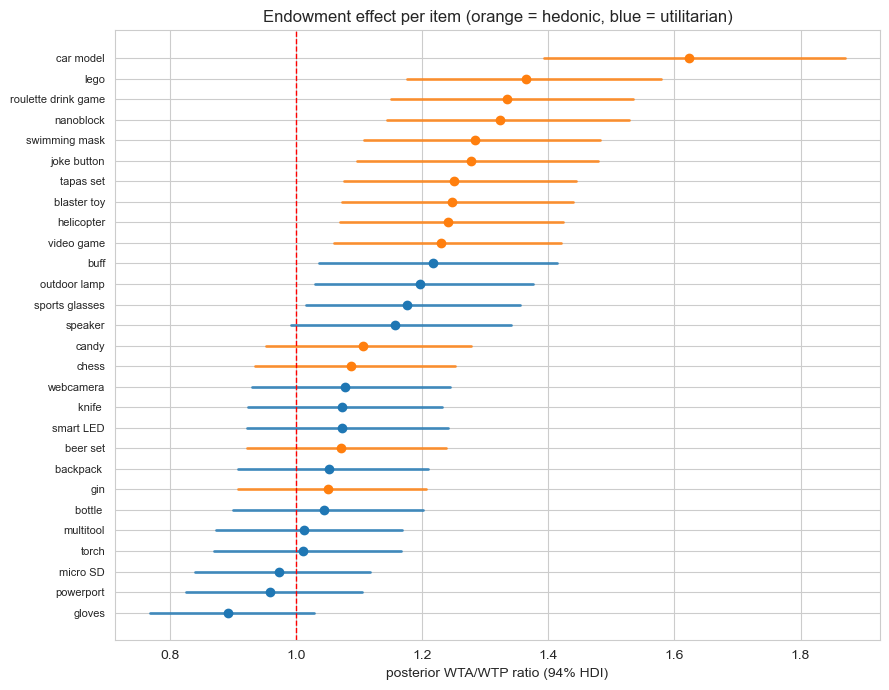

items with P(ratio>1) > 0.95: 14 / 28


In [30]:
post_e1 = idata_e1.posterior
# per-item ratio posterior: exp(mu0 + g_item)
flat2 = post_e1.stack(s=("chain", "draw"))
ratio_item = np.exp(flat2["mu0"].transpose("s").values[:, None]
                    + flat2["g_item"].transpose("s", "item").values)   # (S, item)

item_type = e_df.groupby("Item")[["Type"]].first().loc[coords_e["item"]]
order = np.argsort(ratio_item.mean(0))

fig, ax = plt.subplots(figsize=(9, 7))
colors = np.where(item_type.Type.values[order] == "h", "tab:orange", "tab:blue")
for k, idx in enumerate(order):
    lo, hi = np.quantile(ratio_item[:, idx], [0.03, 0.97])
    ax.plot([lo, hi], [k, k], color=colors[k], lw=2, alpha=0.8)
    ax.plot(ratio_item[:, idx].mean(), k, "o", color=colors[k])
ax.axvline(1, color="red", ls="--", lw=1)
ax.set_yticks(range(len(order)), np.array(coords_e["item"])[order], fontsize=8)
ax.set_xlabel("posterior WTA/WTP ratio (94% HDI)")
ax.set_title("Endowment effect per item (orange = hedonic, blue = utilitarian)")
fig.tight_layout()
save_fig(fig, "endowment_items.png")
plt.show()

p_gt1 = (ratio_item > 1).mean(0)
print(f"items with P(ratio>1) > 0.95: {(p_gt1 > 0.95).sum()} / {len(p_gt1)}")

### 6.1 Hedonic vs utilitarian (paper Fig. 9)

A compact model with the good **type** as the cluster:

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_type, sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 1 seconds.


saved: figures/endowment_categories.png


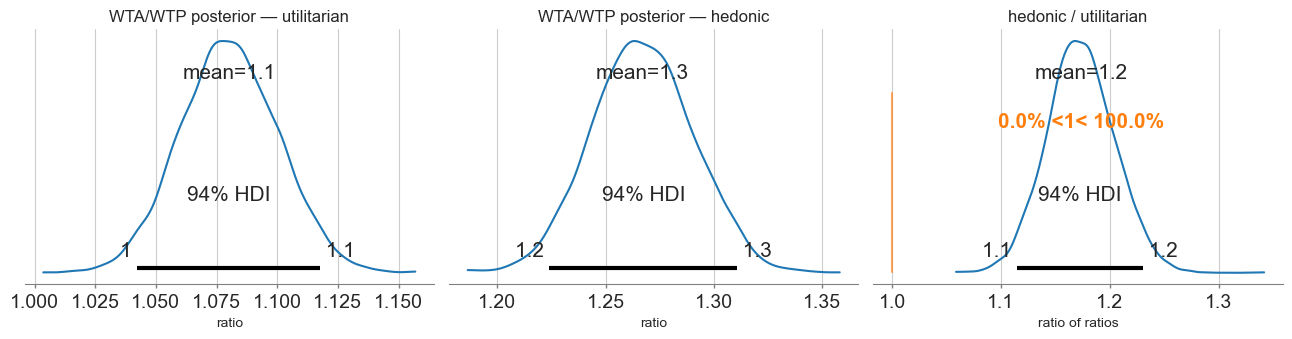

P(hedonic > utilitarian) = 1.0


In [31]:
coords_t = {"type": ["utilitarian", "hedonic"], "obs_id": np.arange(len(e_df))}
with pm.Model(coords=coords_t) as model_e2:
    mu_type = pm.Normal("mu_type", 0, 0.5, dims="type")
    sigma = pm.HalfNormal("sigma", 0.5)
    pm.LogNormal("ratio_obs", mu_type[e_df.TypeCode.values], sigma, observed=e_df.ratio.values)
    idata_e2 = pm.sample(draws=DRAWS, tune=TUNE, chains=4, random_seed=RANDOM_SEED)

diff = (idata_e2.posterior["mu_type"].sel(type="hedonic")
        - idata_e2.posterior["mu_type"].sel(type="utilitarian")).values.flatten()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
az.plot_posterior(np.exp(idata_e2.posterior["mu_type"].sel(type="utilitarian").values.flatten()),
                  point_estimate="mean", hdi_prob=0.94, ax=axes[0])
axes[0].set_title("WTA/WTP posterior — utilitarian"); axes[0].set_xlabel("ratio")
az.plot_posterior(np.exp(idata_e2.posterior["mu_type"].sel(type="hedonic").values.flatten()),
                  point_estimate="mean", hdi_prob=0.94, ax=axes[1])
axes[1].set_title("WTA/WTP posterior — hedonic"); axes[1].set_xlabel("ratio")
az.plot_posterior(np.exp(diff), ref_val=1, hdi_prob=0.94, ax=axes[2])
axes[2].set_title("hedonic / utilitarian"); axes[2].set_xlabel("ratio of ratios")
fig.tight_layout()
save_fig(fig, "endowment_categories.png")
plt.show()
print("P(hedonic > utilitarian) =", (diff > 0).mean())

### 6.2 Item-level testosterone shifts (paper Fig. 10)

Per-item slopes $b_{	ext{item}}$, partially pooled around a global mean — a regularised version of
the original per-item independent slopes:

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu0, g_item, sigma_subj, z_subj, b_global, sigma_b, z_b, sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 10 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


saved: figures/endowment_bT_items.png


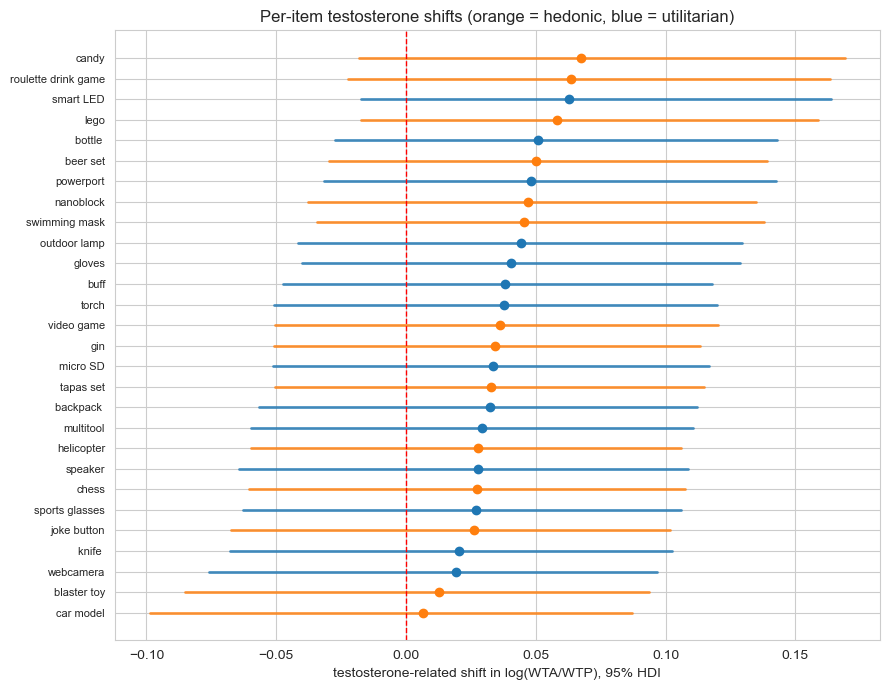

items with 95% HDI excluding 0: 0


In [32]:
with pm.Model(coords=coords_e) as model_e3:
    mu0 = pm.Normal("mu0", 0, 0.5)
    g_item = pm.Normal("g_item", 0, 0.5, dims="item")
    sigma_subj = pm.HalfNormal("sigma_subj", 0.5)
    z_subj = pm.Normal("z_subj", 0, 1, dims="subj")
    b_global = pm.Normal("b_global", 0, 0.25)
    sigma_b = pm.HalfNormal("sigma_b", 0.25)
    z_b = pm.Normal("z_b", 0, 1, dims="item")
    b_item = pm.Deterministic("b_item", b_global + sigma_b * z_b, dims="item")
    sigma = pm.HalfNormal("sigma", 0.5)
    mu = (mu0 + g_item[e_df.ItemCode.values] + sigma_subj * z_subj[e_df.SubjCode.values]
          + b_item[e_df.ItemCode.values] * e_df.TPl_change.values)
    pm.LogNormal("ratio_obs", mu, sigma, observed=e_df.ratio.values)
    idata_e3 = pm.sample(draws=DRAWS, tune=TUNE, chains=4, target_accept=0.97, random_seed=RANDOM_SEED)

b_hat = (idata_e3.posterior["b_item"].stack(s=("chain", "draw"))
         .transpose("s", "item").values)   # (S, item)
b_hdi = az.hdi(idata_e3, var_names=["b_item"], hdi_prob=0.95)["b_item"].values
order_b = np.argsort(b_hat.mean(0))

fig, ax = plt.subplots(figsize=(9, 7))
colors_b = np.where(item_type.Type.values[order_b] == "h", "tab:orange", "tab:blue")
for k, idx in enumerate(order_b):
    ax.plot(b_hdi[idx], [k, k], color=colors_b[k], lw=2, alpha=0.8)
    ax.plot(b_hat[:, idx].mean(), k, "o", color=colors_b[k])
ax.axvline(0, color="red", ls="--", lw=1)
ax.set_yticks(range(len(order_b)), np.array(coords_e["item"])[order_b], fontsize=8)
ax.set_xlabel("testosterone-related shift in log(WTA/WTP), 95% HDI")
ax.set_title("Per-item testosterone shifts (orange = hedonic, blue = utilitarian)")
fig.tight_layout()
save_fig(fig, "endowment_bT_items.png")
plt.show()
print("items with 95% HDI excluding 0:", int((np.sign(b_hdi[:, 0]) == np.sign(b_hdi[:, 1])).sum()))

## 7. What the re-analysis says

| Question | Finding | Matches paper? |
|---|---|---|
| Did testosterone rise? | yes: 18.5 → 33.8 nmol/L under gel, unchanged under placebo | ✔ |
| Risk-taking, positive framing | sensitivity to gains **up** under testosterone ($\delta\beta_{Gain}$ 94% HDI excludes 0) | ✔ (Table 2) |
| Risk-taking, negative framing | shift further toward the sure option (negative $\delta a_{Loss}$, HDI includes 0) | ✔ |
| Model quality | hierarchical M3 clearly best (WAIC/LOO, ROC-AUC ≈ 0.94 vs 0.76 pooled) | ✔ |
| Endowment effect | yes, ratio ≈ 1.15 (geometric mean), nearly all items credibly > 1 | ✔ |
| Hedonic vs utilitarian | hedonic endowment ≈ 1.27 vs utilitarian ≈ 1.08, $P(>) = 1.0$ | ✔ |
| Testosterone → endowment | no meaningful effect; global slope ≈ 0.04 (≈3% at median change), no item credible | ✔ (nuance below) |

**Nuance.** With the paper's own lognormal specification the *global* testosterone slope has a 94%
HDI that barely excludes zero (+0.000…+0.074). The effect size is ~3% at the median hormonal change
and no item survives individually — practically negligible, and the honest reading stays "no
meaningful effect", but reporting the borderline interval is more informative than a binary
"null result".

### Technical modernisation (PyMC3 → PyMC 5)

* `theano` → `pytensor`; `pm.math.invlogit` unchanged; `tt.sgn` → `pt.sign`.
* `pm.Binomial(n=1, ...)` → `pm.Bernoulli`.
* ArviZ: `credible_interval` → `hdi_prob`; `pm.hpd` → `az.hdi`; `az.from_pymc3` no longer needed —
  `pm.sample` returns an `InferenceData` directly (with `log_likelihood` on demand).
* `pm.sample(draws, tune, ...)` positional `init='advi'` dropped — NUTS' jitter+adapt diag init is
  more robust here; sampling of the winning model takes ~15 s (vs minutes in PyMC3).
* Subject-level effects reparameterised as **non-centered** (`z * sigma`, `LKJCholeskyCov` +
  `dot(chol, z)`) — removes the funnel/centre-pathologies of the original parameterisation.
* Endowment model now follows the paper's *described* lognormal form (log link), replacing the raw
  Normal likelihood + outlier clipping + ad-hoc added half-Cauchy sds of the original notebook.
* Posterior θ stored as a `Deterministic` — no manual PPC plumbing needed for the ROC-AUC check.

## References

* Votinov, M., Knyazeva, I., Habel, U., Konrad, K., & Puiu, A. A. (2022). A Bayesian Modeling
  Approach to Examine the Role of Testosterone Administration on the Endowment Effect and
  Risk-Taking. *Frontiers in Neuroscience*, 16, 858168.
* Nilsson, H., Rieskamp, J., & Wagenmakers, E.-J. (2011). Hierarchical Bayesian parameter
  estimation for cumulative prospect theory. *Journal of Mathematical Psychology*, 55(1), 84–93.
* Tversky, A., & Kahneman, D. (1992). Advances in prospect theory: Cumulative representation of
  uncertainty. *Journal of Risk and Uncertainty*, 5, 297–323.
* McElreath, R. (2020). *Statistical Rethinking* (2nd ed.). CRC Press.

*Data and original PyMC3 notebooks: `RiskTestosterone` project (github.com/iknyazeva/RiskTestosterone),
OSF `sbxm2` for the Rieskamp/Nilsson data.*